# 05 -- Robustness & Hyperparameter Sensitivity

Sensitivity of the winning topology from Notebook 04 to: basis size,
regularisation strengths, estimator mode, endpoint method, and diffusion
estimation mode.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from chromlearn import find_repo_root

ROOT = find_repo_root(Path(__file__).resolve().parent if "__file__" in dir() else Path.cwd())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from chromlearn.io.catalog import load_condition
from chromlearn.io.trajectory import trim_trajectory
from chromlearn.model_fitting import FitConfig
from chromlearn.model_fitting.basis import BSplineBasis
from chromlearn.model_fitting.diffusion import local_diffusion_estimates
from chromlearn.model_fitting.features import build_design_matrix
from chromlearn.model_fitting.fit import (
    CVResult,
    ForecastHorizonResult,
    RolloutCVResult,
    cross_validate,
    evaluate_all_loocv,
    fit_kernels,
    fit_model,
    forecast_horizon_cross_validate,
    rollout_cross_validate,
)
from chromlearn.model_fitting.model import FittedModel
from chromlearn.model_fitting.plotting import plot_cv_curve, plot_kernels

plt.rcParams["figure.dpi"] = 110

## Setup

In [2]:
# --- Must match Notebook 04 settings ---
# Update WINNING_TOPOLOGY after consulting NB04 results.
# Basis domains must match NB04 (R_MIN=0.3, R_MAX=15.0) to ensure
# robustness checks probe the same model, not a different domain.
CONDITION = "rpe18_ctr"          # Control-condition cells used in the robustness sweeps.
WINNING_TOPOLOGY = "poles_and_chroms"  # Base FitConfig topology; short-range variant is encoded by the envelope (matches NB04's poles_and_chroms_enveloped winner).
ENVELOPE_R0_XX = 1.5             # Center of the smooth steric envelope on the xx kernel (um); matches NB04.
ENVELOPE_W_XX = 0.3              # Transition width of the envelope (um); matches NB04.
FRAC_NEB_AO_WINDOW = 0.4         # Baseline trajectory window as a fraction of NEB-to-AO.
N_BASIS_XX = 10                  # Number of spline basis functions for chromosome-chromosome kernels.
N_BASIS_XY = 10                  # Number of spline basis functions for pole-chromosome kernels.
R_MIN = 0.3   # um               # Lower basis cutoff, set by tracking resolution.
R_MAX = 15.0  # um               # Upper basis cutoff, set by spindle-scale geometry.
LAMBDA_RIDGE = 1e-6              # Fixed numerical jitter; not a tuning knob.
LAMBDA_ROUGH = 1.0               # Integrated 2nd-derivative penalty (controls kernel smoothness).
BASIS_EVAL_MODE = "ito"          # Drift-evaluation convention used throughout the main analysis.
DIFFUSION_MODE = "msd"           # Baseline diffusion estimator used in the fit.
DT = 5.0                         # Frame interval in seconds.

cells_raw = load_condition(CONDITION)
cells = [trim_trajectory(c, method="neb_ao_frac", frac=FRAC_NEB_AO_WINDOW) for c in cells_raw]
print(f"Loaded {len(cells)} {CONDITION} cells (trimmed to neb_ao_frac={FRAC_NEB_AO_WINDOW:.3f} window).")

BASE_CONFIG = FitConfig(
    topology=WINNING_TOPOLOGY,
    envelope_r0_xx=ENVELOPE_R0_XX,
    envelope_w_xx=ENVELOPE_W_XX,
    n_basis_xx=N_BASIS_XX,
    n_basis_xy=N_BASIS_XY,
    r_min_xx=R_MIN,
    r_max_xx=R_MAX,
    r_min_xy=R_MIN,
    r_max_xy=R_MAX,
    lambda_ridge=LAMBDA_RIDGE,
    lambda_rough=LAMBDA_ROUGH,
    basis_eval_mode=BASIS_EVAL_MODE,
    endpoint_method="neb_ao_frac",
    endpoint_frac=FRAC_NEB_AO_WINDOW,
    diffusion_mode=DIFFUSION_MODE,
    dt=DT,
)

ROLLOUT_HORIZONS = (1, 5, 10, 20)
H_PRIMARY = 10  # Primary held-out horizon (frames). Matches NB04.
assert H_PRIMARY in ROLLOUT_HORIZONS
FORECAST_HORIZONS = (H_PRIMARY,)  # Rolling-window forecast scored at H_PRIMARY only.


def _h_primary_idx(result: RolloutCVResult) -> int:
    return list(result.horizons).index(H_PRIMARY)


def rollout_path_score(result: RolloutCVResult) -> float:
    """Primary rollout score: per-chromosome 3D path MSE on held-out cells."""
    return float(np.nanmean(result.path_mse))


def rollout_path_se(result: RolloutCVResult) -> float:
    """SE across held-out cells for the path MSE."""
    valid = result.path_mse[np.isfinite(result.path_mse)]
    if valid.size == 0:
        return np.inf
    return float(np.nanstd(valid) / np.sqrt(valid.size))


def rollout_ensemble_score(result: RolloutCVResult) -> float:
    """Diagnostic: deterministic drift-rollout ensemble MSE at horizon
    H_PRIMARY frames (Alex's docx anchor).  Primary criterion is path MSE."""
    h = _h_primary_idx(result)
    return float(np.nanmean(result.horizon_ensemble_mse[:, h]))


def rollout_ensemble_se(result: RolloutCVResult) -> float:
    """SE across held-out cells for the ensemble MSE at H_PRIMARY."""
    h = _h_primary_idx(result)
    vals = result.horizon_ensemble_mse[:, h]
    valid = vals[np.isfinite(vals)]
    if valid.size == 0:
        return np.inf
    return float(np.nanstd(valid) / np.sqrt(valid.size))


def rollout_w1_score(result: RolloutCVResult) -> float:
    """Final-frame distribution mismatch: axial W1 + radial W1."""
    return float(
        np.nanmean(result.final_axial_wasserstein)
        + np.nanmean(result.final_radial_wasserstein)
    )


def forecast_score(result: ForecastHorizonResult) -> float:
    """Rolling-window forecast ensemble MSE at H_PRIMARY (LOOCV)."""
    h_idx = list(result.horizons).index(H_PRIMARY)
    return float(np.nanmean(result.ensemble_mse[:, h_idx]))


def forecast_se(result: ForecastHorizonResult) -> float:
    """SE across held-out cells for the forecast ensemble MSE at H_PRIMARY."""
    h_idx = list(result.horizons).index(H_PRIMARY)
    vals = result.ensemble_mse[:, h_idx]
    valid = vals[np.isfinite(vals)]
    if valid.size == 0:
        return np.inf
    return float(np.nanstd(valid) / np.sqrt(valid.size))


def run_rollout_cv(
    cells_in: list,
    cfg: FitConfig,
    k_folds: int | None = None,
) -> RolloutCVResult:
    """Deterministic drift-rollout CV helper for sweep comparisons."""
    return rollout_cross_validate(
        cells_in,
        cfg,
        horizons=ROLLOUT_HORIZONS,
        k_folds=k_folds,
        deterministic=True,
    )

Loaded 12 rpe18_ctr cells (trimmed to neb_ao_frac=0.400 window).


(Sweep 0 -- rollout replicate convergence -- removed.  With deterministic
drift rollouts there is no stochastic variance to converge.)

## Sweep 1: Joint (n\_basis, lambda\_rough) grid

We sweep the two regularization knobs that affect the inferred kernel
*shape*: number of B-spline basis functions and the integrated 2nd-derivative
smoothness penalty `lambda_rough`. The L2 ridge `lambda_ridge` is fixed at
`1e-6` (numerical jitter) and not swept: we are not interpreting individual
basis coefficients or seeking sparsity in the coefficient vector, only the
output kernel function predictions, so a coefficient-norm penalty has no
physical role here.

We use the deterministic drift-rollout path MSE (full-trajectory ensemble
MSE, matching NB04) as the primary selection target.  Ensemble MSE @ h=10,
rolling-window forecast, W1, and 1-step CV are recorded as supporting
diagnostics.

In [3]:
from itertools import product as _product  # noqa: E402

N_BASIS_GRID = [6, 8, 10, 12, 16]
LAMBDA_ROUGH_GRID = np.array([1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2])

grid_configs = list(_product(N_BASIS_GRID, LAMBDA_ROUGH_GRID))
n_grid = len(grid_configs)
print(f"Joint grid: {len(N_BASIS_GRID)} x {len(LAMBDA_ROUGH_GRID)} = {n_grid} configs"
      f"  (lambda_ridge fixed at {LAMBDA_RIDGE:.0e})")


def _run_one_grid_point(
    cells_in,
    base_cfg,
    rollout_horizons,
    forecast_horizons,
    k_folds,
    compute_one_step_cv,
    nb,
    lro,
):
    """Worker function for parallel grid sweep (all args explicit for joblib).

    Uses evaluate_all_loocv to fit ONCE per fold and evaluate all three
    metrics (1-step CV, from-NEB rollout, rolling-window forecast) against
    the same FittedModel.  Numerically equivalent to calling cross_validate /
    rollout_cross_validate (deterministic=True) / forecast_horizon_cross_validate
    (deterministic=True) separately, but skips the redundant refits.
    Note: k_folds is ignored (LOO only); forecast_horizon_cross_validate
    has no k_folds parameter, so to keep all three metrics aligned we
    always run LOOCV in this worker.
    """
    cfg = FitConfig(
        topology=base_cfg.topology,
        envelope_r0_xx=base_cfg.envelope_r0_xx,
        envelope_w_xx=base_cfg.envelope_w_xx,
        n_basis_xx=nb,
        n_basis_xy=nb,
        r_min_xx=base_cfg.r_min_xx,
        r_max_xx=base_cfg.r_max_xx,
        r_min_xy=base_cfg.r_min_xy,
        r_max_xy=base_cfg.r_max_xy,
        basis_type=base_cfg.basis_type,
        lambda_ridge=LAMBDA_RIDGE,
        lambda_rough=lro,
        basis_eval_mode=base_cfg.basis_eval_mode,
        endpoint_method=base_cfg.endpoint_method,
        endpoint_frac=base_cfg.endpoint_frac,
        diffusion_mode=base_cfg.diffusion_mode,
        dt=base_cfg.dt,
    )
    cv_result, rollout_result, forecast_result = evaluate_all_loocv(
        cells_in, cfg,
        rollout_horizons=rollout_horizons,
        forecast_horizons=forecast_horizons,
        compute_one_step=compute_one_step_cv,
    )
    return (nb, lro), cv_result, rollout_result, forecast_result


import os  # noqa: E402

from joblib import Parallel, delayed  # noqa: E402

N_WORKERS = min(os.cpu_count() or 1, n_grid)


def _run_grid_sweep(
    cells_in,
    base_cfg,
    grid_configs_in,
    rollout_horizons,
    forecast_horizons,
    *,
    k_folds: int | None,
    label: str,
    compute_one_step_cv: bool = True,
    print_config_scores: bool = True,
    joblib_verbose: int = 10,
    announce: bool = True,
) -> tuple[
    dict[tuple, CVResult],
    dict[tuple, RolloutCVResult],
    dict[tuple, ForecastHorizonResult],
]:
    """Run the joint (n_basis, lambda_rough) grid under a chosen CV design."""
    if announce:
        print(f"Running {label} grid sweep with {N_WORKERS} parallel workers (joblib/loky)...")
    grid_cv_local: dict[tuple, CVResult] = {}
    grid_rollout_local: dict[tuple, RolloutCVResult] = {}
    grid_forecast_local: dict[tuple, ForecastHorizonResult] = {}

    results = Parallel(n_jobs=N_WORKERS, verbose=joblib_verbose)(
        delayed(_run_one_grid_point)(
            cells_in, base_cfg, rollout_horizons, forecast_horizons,
            k_folds, compute_one_step_cv, nb, lro,
        )
        for nb, lro in grid_configs_in
    )

    for key, cv_result, rollout_result, forecast_result in results:
        if cv_result is not None:
            grid_cv_local[key] = cv_result
        grid_rollout_local[key] = rollout_result
        grid_forecast_local[key] = forecast_result
        if print_config_scores:
            nb, lro = key
            cv_part = (
                f"  1-step={cv_result.mean_error:.4e}"
                if cv_result is not None else ""
            )
            print(
                f"  n_basis={nb}, rough={lro:.0e}"
                f"{cv_part}"
                f"  ens_MSE={rollout_ensemble_score(rollout_result):.4e}"
                f"  forecast={forecast_score(forecast_result):.4e}"
                f"  path_MSE={rollout_path_score(rollout_result):.4e}"
                f"  W1={rollout_w1_score(rollout_result):.4e}"
            )

    if announce:
        print(f"{label} grid sweep complete: {len(grid_rollout_local)} configs evaluated.")
    return grid_cv_local, grid_rollout_local, grid_forecast_local


grid_cv, grid_rollout, grid_forecast = _run_grid_sweep(
    cells,
    BASE_CONFIG,
    grid_configs,
    ROLLOUT_HORIZONS,
    FORECAST_HORIZONS,
    k_folds=None,
    label="LOO",
)

Joint grid: 5 x 6 = 30 configs  (lambda_ridge fixed at 1e-06)
Running LOO grid sweep with 16 parallel workers (joblib/loky)...


[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.


[Parallel(n_jobs=16)]: Done   3 out of  30 | elapsed:   51.6s remaining:  7.7min


[Parallel(n_jobs=16)]: Done   7 out of  30 | elapsed:   53.3s remaining:  2.9min


[Parallel(n_jobs=16)]: Done  11 out of  30 | elapsed:  1.4min remaining:  2.4min


...

[Parallel(n_jobs=16)]: Done  19 out of  30 | elapsed:  1.8min remaining:  1.1min


[Parallel(n_jobs=16)]: Done  23 out of  30 | elapsed:  1.9min remaining:   34.6s


[Parallel(n_jobs=16)]: Done  27 out of  30 | elapsed:  2.4min remaining:   16.2s


  n_basis=6, rough=1e-03  1-step=7.7575e-04  ens_MSE=1.5931e+00  forecast=8.6353e-01  path_MSE=5.2407e+00  W1=1.6694e+00
  n_basis=6, rough=1e-02  1-step=7.7575e-04  ens_MSE=1.5931e+00  forecast=8.6353e-01  path_MSE=5.2407e+00  W1=1.6694e+00
  n_basis=6, rough=1e-01  1-step=7.7575e-04  ens_MSE=1.5931e+00  forecast=8.6353e-01  path_MSE=5.2406e+00  W1=1.6694e+00
  n_basis=6, rough=1e+00  1-step=7.7575e-04  ens_MSE=1.5931e+00  forecast=8.6352e-01  path_MSE=5.2404e+00  W1=1.6693e+00
  n_basis=6, rough=1e+01  1-step=7.7574e-04  ens_MSE=1.5929e+00  forecast=8.6346e-01  path_MSE=5.2399e+00  W1=1.6689e+00
  n_basis=6, rough=1e+02  1-step=7.7572e-04  ens_MSE=1.5921e+00  forecast=8.6330e-01  path_MSE=5.2398e+00  W1=1.6675e+00
  n_basis=8, rough=1e-03  1-step=7.7587e-04  ens_MSE=1.5937e+00  forecast=8.6341e-01  path_MSE=5.2434e+00  W1=1.6682e+00
  n_basis=8, rough=1e-02  1-step=7.7578e-04  ens_MSE=1.5937e+00  forecast=8.6339e-01  path_MSE=5.2434e+00  W1=1.6682e+00
  n_basis=8, rough=1e-01  1-step

[Parallel(n_jobs=16)]: Done  30 out of  30 | elapsed:  2.5min finished


In [4]:
# Report winners under each metric.  Primary criterion is path MSE
# (full-trajectory ensemble MSE), matching NB04.  The h=10 ensemble MSE,
# rolling-window forecast, and 1-step CV are reported as supporting
# diagnostics.
#   - Path MSE (PRIMARY): mean squared error over all frames, full
#     trajectory.  Matches NB04's selection criterion.
#   - 1-step CV: instantaneous drift accuracy (single-frame prediction).
#   - From-NEB ensemble MSE @ H_PRIMARY: Alex's diagnostic horizon (50 s).
#   - Rolling-window forecast @ H_PRIMARY: error h frames ahead, averaged
#     over all starting points (restart from real positions each window).
best_key = min(grid_configs, key=lambda k: rollout_path_score(grid_rollout[k]))
best_n_basis_rollout, best_rough_rollout = best_key
best_key_cv = min(grid_configs, key=lambda k: grid_cv[k].mean_error)
best_key_ens = min(grid_configs, key=lambda k: rollout_ensemble_score(grid_rollout[k]))
best_key_forecast = min(grid_configs, key=lambda k: forecast_score(grid_forecast[k]))

print(f"\nBest by path MSE (PRIMARY):                     n_basis={best_key[0]}, "
      f"lambda_rough={best_key[1]:.2e}  "
      f"(path MSE = {rollout_path_score(grid_rollout[best_key]):.4e})")
print(f"Best by ensemble MSE @h={H_PRIMARY} (from NEB): n_basis={best_key_ens[0]}, "
      f"lambda_rough={best_key_ens[1]:.2e}  "
      f"(ens MSE = {rollout_ensemble_score(grid_rollout[best_key_ens]):.4e})")
print(f"Best by rolling-window forecast @h={H_PRIMARY}: n_basis={best_key_forecast[0]}, "
      f"lambda_rough={best_key_forecast[1]:.2e}  "
      f"(forecast MSE = {forecast_score(grid_forecast[best_key_forecast]):.4e})")
print(f"Best by 1-step CV:                              n_basis={best_key_cv[0]}, "
      f"lambda_rough={best_key_cv[1]:.2e}  "
      f"(CV MSE = {grid_cv[best_key_cv].mean_error:.4e})")
print(
    "\nNOTE: NB06 and NB07 hard-code their own (n_basis, lambda_rough) and "
    "envelope params.  After this sweep, manually update those notebooks to "
    "the chosen winner before re-running them."
)


Best by path MSE (PRIMARY):                     n_basis=12, lambda_rough=1.00e+02  (path MSE = 5.2219e+00)
Best by ensemble MSE @h=10 (from NEB): n_basis=6, lambda_rough=1.00e+02  (ens MSE = 1.5921e+00)
Best by rolling-window forecast @h=10: n_basis=12, lambda_rough=1.00e+01  (forecast MSE = 8.6221e-01)
Best by 1-step CV:                              n_basis=12, lambda_rough=1.00e+01  (CV MSE = 7.7571e-04)

NOTE: NB06 and NB07 hard-code their own (n_basis, lambda_rough) and envelope params.  After this sweep, manually update those notebooks to the chosen winner before re-running them.


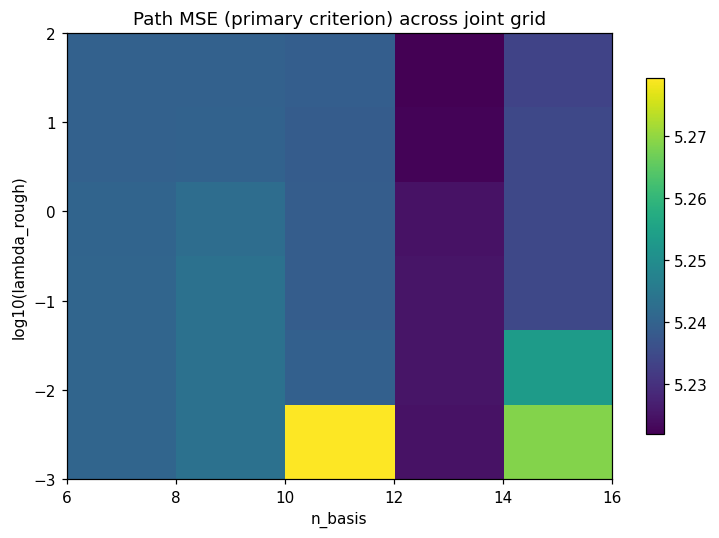

In [5]:
# 2D heatmap: n_basis x lambda_rough, primary criterion (path MSE)
mat_nro = np.full((len(LAMBDA_ROUGH_GRID), len(N_BASIS_GRID)), np.nan)
for xi, nb in enumerate(N_BASIS_GRID):
    for yi, lro in enumerate(LAMBDA_ROUGH_GRID):
        key = (nb, lro)
        if key in grid_rollout:
            mat_nro[yi, xi] = rollout_path_score(grid_rollout[key])

fig_slice, ax_slice = plt.subplots(1, 1, figsize=(7, 5))
im = ax_slice.imshow(
    mat_nro, origin="lower", aspect="auto",
    extent=[
        N_BASIS_GRID[0], N_BASIS_GRID[-1],
        np.log10(LAMBDA_ROUGH_GRID[0]), np.log10(LAMBDA_ROUGH_GRID[-1]),
    ],
)
ax_slice.set_xlabel("n_basis")
ax_slice.set_ylabel("log10(lambda_rough)")
ax_slice.set_title("Path MSE (primary criterion) across joint grid")
fig_slice.colorbar(im, ax=ax_slice, shrink=0.8)
fig_slice.tight_layout()
plt.show()

### 1D marginal views

For each hyperparameter, show the best path MSE achieved at each
value (minimizing over the other one). The min-max band shows the spread
across the other axis.

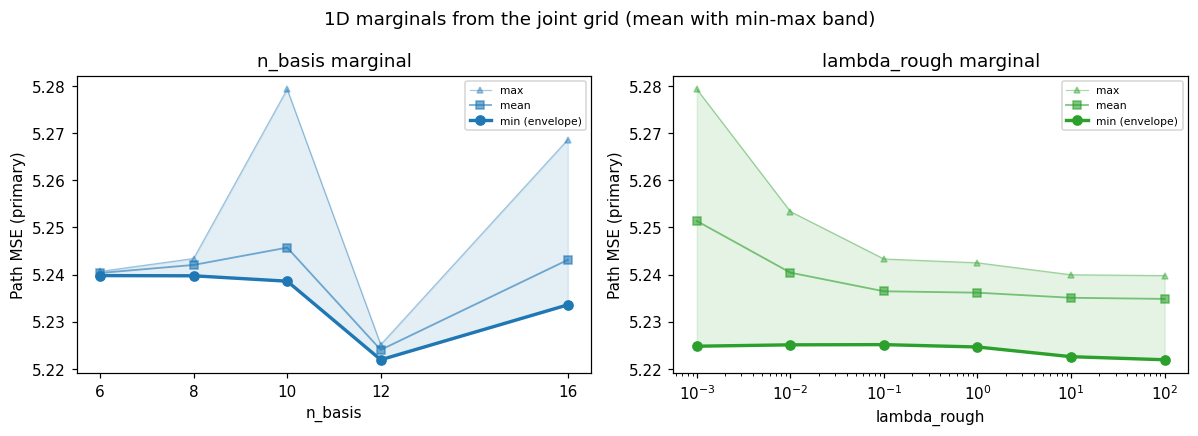

In [6]:
def _marginal_stats(scores, configs, param_idx, param_vals):
    """Min, mean, max of scores grouped by one hyperparameter axis."""
    lo, mid, hi = [], [], []
    for v in param_vals:
        group = [scores[k] for k in configs if k[param_idx] == v]
        lo.append(min(group))
        mid.append(np.mean(group))
        hi.append(max(group))
    return np.array(lo), np.array(mid), np.array(hi)


def _plot_marginal(ax, x, lo, mid, hi, color, xlabel, ylabel, title, xlog=False):
    ax.fill_between(x, lo, hi, alpha=0.12, color=color)
    ax.plot(x, hi, "^-", color=color, linewidth=0.8, markersize=4, alpha=0.4, label="max")
    ax.plot(x, mid, "s-", color=color, linewidth=1.2, markersize=5, alpha=0.6, label="mean")
    ax.plot(x, lo, "o-", color=color, linewidth=2.2, markersize=6, label="min (envelope)")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=7)
    if xlog:
        ax.set_xscale("log")


grid_scores_loo = {k: rollout_path_score(grid_rollout[k]) for k in grid_configs}

nb_lo, nb_mid, nb_hi = _marginal_stats(grid_scores_loo, grid_configs, 0, N_BASIS_GRID)
lro_lo, lro_mid, lro_hi = _marginal_stats(grid_scores_loo, grid_configs, 1, LAMBDA_ROUGH_GRID)

nb_best, lro_best = nb_lo, lro_lo

fig_marginal, axes_m = plt.subplots(1, 2, figsize=(11, 4))
_plot_marginal(axes_m[0], N_BASIS_GRID, nb_lo, nb_mid, nb_hi, "C0",
               "n_basis", "Path MSE (primary)", "n_basis marginal")
axes_m[0].set_xticks(N_BASIS_GRID)
_plot_marginal(axes_m[1], LAMBDA_ROUGH_GRID, lro_lo, lro_mid, lro_hi, "C2",
               "lambda_rough", "Path MSE (primary)", "lambda_rough marginal", xlog=True)

fig_marginal.suptitle("1D marginals from the joint grid (mean with min-max band)", fontsize=12)
fig_marginal.tight_layout()
plt.show()

### Kernel shape stability across the grid

Fit each of the n_grid configs on all cells and plot the resulting
chrom-pole kernel.  The spaghetti cloud shows the full variation; the
marginal slices color by the swept parameter.

In [7]:
from matplotlib.colors import LogNorm  # noqa: E402

print(f"Fitting models for all {n_grid} grid configs (all cells, no CV)...")
grid_models: dict[tuple, FittedModel] = {}
for nb, lro in grid_configs:
    cfg = FitConfig(
        topology=BASE_CONFIG.topology,
        envelope_r0_xx=BASE_CONFIG.envelope_r0_xx,
        envelope_w_xx=BASE_CONFIG.envelope_w_xx,
        n_basis_xx=nb,
        n_basis_xy=nb,
        r_min_xx=BASE_CONFIG.r_min_xx,
        r_max_xx=BASE_CONFIG.r_max_xx,
        r_min_xy=BASE_CONFIG.r_min_xy,
        r_max_xy=BASE_CONFIG.r_max_xy,
        basis_type=BASE_CONFIG.basis_type,
        lambda_ridge=LAMBDA_RIDGE,
        lambda_rough=lro,
        basis_eval_mode=BASE_CONFIG.basis_eval_mode,
        endpoint_method=BASE_CONFIG.endpoint_method,
        endpoint_frac=BASE_CONFIG.endpoint_frac,
        diffusion_mode=BASE_CONFIG.diffusion_mode,
        dt=BASE_CONFIG.dt,
    )
    grid_models[(nb, lro)] = fit_model(cells, cfg)
print(f"  Done: {len(grid_models)} models fitted.")

Fitting models for all 30 grid configs (all cells, no CV)...


  Done: 30 models fitted.


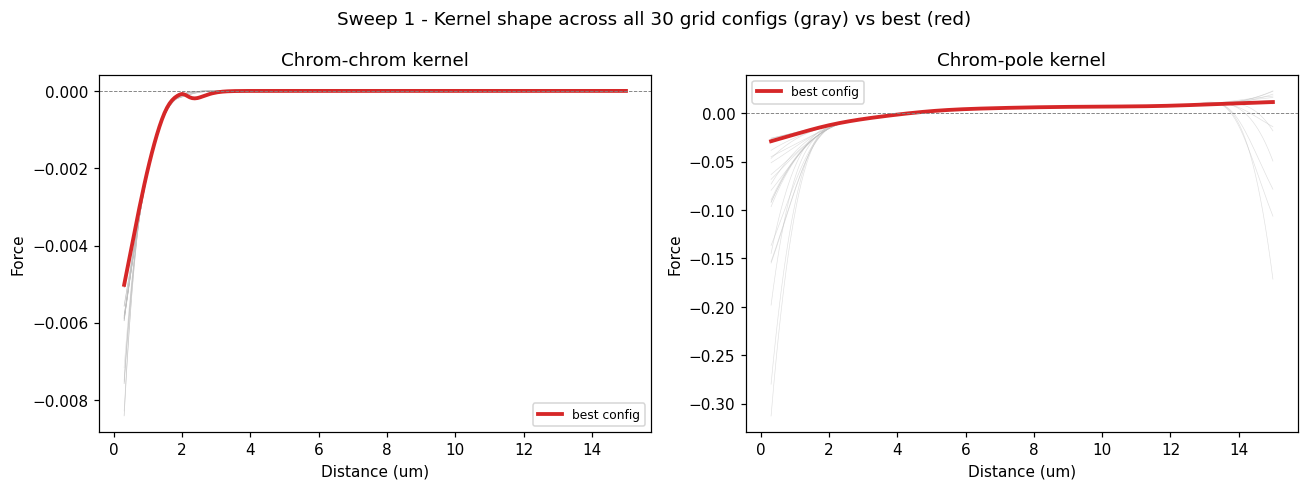

In [8]:
# Spaghetti cloud: all grid configs, best highlighted
_topology_has_chroms_grid = WINNING_TOPOLOGY in ("poles_and_chroms", "center_and_chroms")
_n_kernel_panels = 2 if _topology_has_chroms_grid else 1
_N_EVAL = 200

fig_spaghetti, ax_sp = plt.subplots(
    1, _n_kernel_panels, figsize=(6 * _n_kernel_panels, 4.5), squeeze=False,
)

for key in grid_configs:
    model = grid_models[key]
    if _topology_has_chroms_grid:
        r_xx = np.linspace(model.basis_xx.r_min, model.basis_xx.r_max, _N_EVAL)
        f_xx = model.evaluate_kernel("xx", r_xx)
        ax_sp[0, 0].plot(r_xx, f_xx, color="0.75", linewidth=0.4, alpha=0.5)
    r_xy = np.linspace(model.basis_xy.r_min, model.basis_xy.r_max, _N_EVAL)
    f_xy = model.basis_xy.evaluate(r_xy) @ model.theta_xy
    ax_sp[0, _n_kernel_panels - 1].plot(
        r_xy, f_xy, color="0.75", linewidth=0.4, alpha=0.5,
    )

# Best config in bold
best_model = grid_models[best_key]
if _topology_has_chroms_grid:
    r_xx = np.linspace(best_model.basis_xx.r_min, best_model.basis_xx.r_max, _N_EVAL)
    f_xx = best_model.evaluate_kernel("xx", r_xx)
    ax_sp[0, 0].plot(r_xx, f_xx, color="C3", linewidth=2.5, label="best config")
    ax_sp[0, 0].axhline(0, color="0.5", linestyle="--", linewidth=0.6)
    ax_sp[0, 0].set_xlabel("Distance (um)")
    ax_sp[0, 0].set_ylabel("Force")
    ax_sp[0, 0].set_title("Chrom-chrom kernel")
    ax_sp[0, 0].legend(fontsize=8)

r_xy = np.linspace(best_model.basis_xy.r_min, best_model.basis_xy.r_max, _N_EVAL)
f_xy = best_model.basis_xy.evaluate(r_xy) @ best_model.theta_xy
ax_xy = ax_sp[0, _n_kernel_panels - 1]
ax_xy.plot(r_xy, f_xy, color="C3", linewidth=2.5, label="best config")
ax_xy.axhline(0, color="0.5", linestyle="--", linewidth=0.6)
ax_xy.set_xlabel("Distance (um)")
ax_xy.set_ylabel("Force")
ax_xy.set_title("Chrom-pole kernel")
ax_xy.legend(fontsize=8)

fig_spaghetti.suptitle(
    f"Sweep 1 - Kernel shape across all {n_grid} grid configs (gray) vs best (red)",
    fontsize=12,
)
fig_spaghetti.tight_layout()
plt.show()

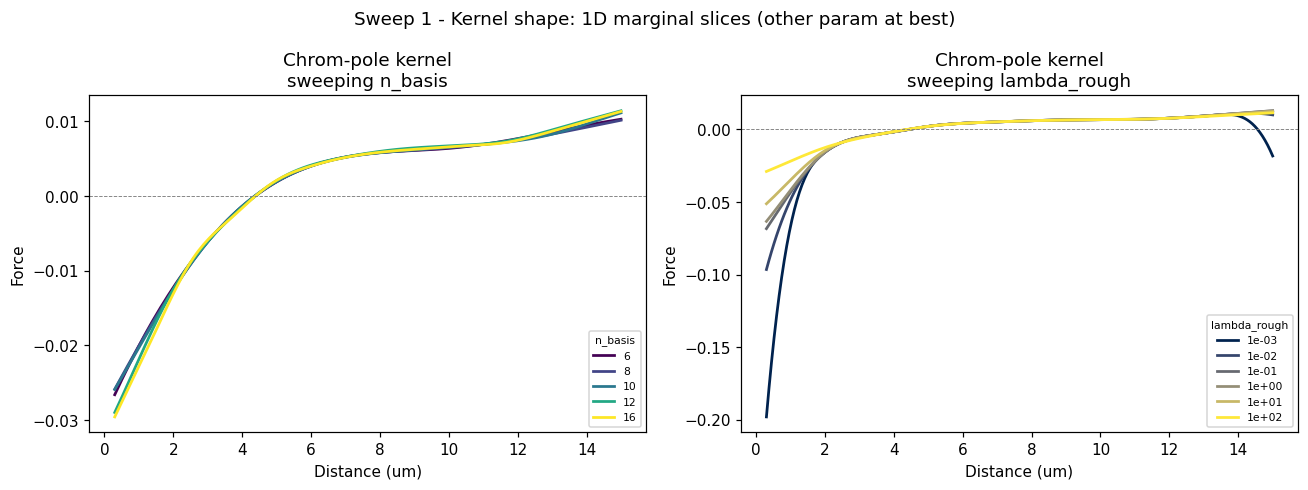

In [9]:
# 1D marginal slices: sweep one parameter, fix the other at best
_param_slices = [
    ("n_basis", 0, N_BASIS_GRID, best_rough_rollout, "viridis", False),
    ("lambda_rough", 1, LAMBDA_ROUGH_GRID, best_n_basis_rollout, "cividis", True),
]

fig_kslice, axes_ks = plt.subplots(
    1, len(_param_slices), figsize=(6 * len(_param_slices), 4.5),
)

for ax, (pname, pidx, pvals, fix_other, cmap_name, is_log) in zip(axes_ks, _param_slices):
    cmap = plt.get_cmap(cmap_name)
    if is_log:
        norm = LogNorm(vmin=pvals[0], vmax=pvals[-1])
    else:
        norm = plt.Normalize(vmin=pvals[0], vmax=pvals[-1])

    for pv in pvals:
        if pidx == 0:
            key = (pv, fix_other)
        else:
            key = (fix_other, pv)
        model = grid_models[key]
        r_xy = np.linspace(model.basis_xy.r_min, model.basis_xy.r_max, _N_EVAL)
        f_xy = model.basis_xy.evaluate(r_xy) @ model.theta_xy
        color = cmap(norm(pv))
        label = f"{pv:.0e}" if is_log else f"{int(pv)}"
        ax.plot(r_xy, f_xy, color=color, linewidth=1.8, label=label)

    ax.axhline(0, color="0.5", linestyle="--", linewidth=0.6)
    ax.set_xlabel("Distance (um)")
    ax.set_ylabel("Force")
    ax.set_title(f"Chrom-pole kernel\nsweeping {pname}")
    ax.legend(fontsize=7, title=pname, title_fontsize=7)

fig_kslice.suptitle(
    "Sweep 1 - Kernel shape: 1D marginal slices (other param at best)",
    fontsize=12,
)
fig_kslice.tight_layout()
plt.show()

## Sweep 2: Estimator mode (Ito / Ito-shift / Stratonovich)

"ito" = current positions, "ito_shift" = previous positions (decorrelates
localisation noise), "strato" = midpoint (Stratonovich convention).
With constant D(x) there is no spurious-drift correction, so all three
conventions should give essentially the same kernel.

In [10]:
ESTIMATOR_MODES = ["ito", "ito_shift", "strato"]

cv_mode: dict[str, CVResult] = {}
rollout_mode: dict[str, RolloutCVResult] = {}
models_mode: dict[str, object] = {}

for idx, mode in enumerate(ESTIMATOR_MODES, start=1):
    cfg = FitConfig(
        topology=BASE_CONFIG.topology,
        envelope_r0_xx=BASE_CONFIG.envelope_r0_xx,
        envelope_w_xx=BASE_CONFIG.envelope_w_xx,
        n_basis_xx=BASE_CONFIG.n_basis_xx,
        n_basis_xy=BASE_CONFIG.n_basis_xy,
        r_min_xx=BASE_CONFIG.r_min_xx,
        r_max_xx=BASE_CONFIG.r_max_xx,
        r_min_xy=BASE_CONFIG.r_min_xy,
        r_max_xy=BASE_CONFIG.r_max_xy,
        basis_type=BASE_CONFIG.basis_type,
        lambda_ridge=BASE_CONFIG.lambda_ridge,
        lambda_rough=BASE_CONFIG.lambda_rough,
        basis_eval_mode=mode,
        endpoint_method=BASE_CONFIG.endpoint_method,
        endpoint_frac=BASE_CONFIG.endpoint_frac,
        diffusion_mode=BASE_CONFIG.diffusion_mode,
        dt=BASE_CONFIG.dt,
    )
    print(f"[Sweep 2 {idx}/{len(ESTIMATOR_MODES)}] mode={mode}: running 1-step LOOCV...", flush=True)
    cv_mode[mode] = cross_validate(cells, cfg)
    print(
        f"    1-step CV = {cv_mode[mode].mean_error:.4e}"
        f" ± {cv_mode[mode].fold_se:.4e}",
        flush=True,
    )
    print(
        f"    running deterministic rollout LOOCV ({len(cells)} folds)...",
        flush=True,
    )
    rollout_mode[mode] = run_rollout_cv(cells, cfg)
    print(
        f"    path MSE = {rollout_path_score(rollout_mode[mode]):.4e}"
        f"  ens MSE @h={H_PRIMARY} = {rollout_ensemble_score(rollout_mode[mode]):.4e}"
        f"  W1 total = {rollout_w1_score(rollout_mode[mode]):.4e}",
        flush=True,
    )
    models_mode[mode] = fit_model(cells, cfg)

[Sweep 2 1/3] mode=ito: running 1-step LOOCV...


    1-step CV = 7.7577e-04 ± 6.7398e-05


    running deterministic rollout LOOCV (12 folds)...


    path MSE = 5.2389e+00  ens MSE @h=10 = 1.5937e+00  W1 total = 1.6705e+00


[Sweep 2 2/3] mode=ito_shift: running 1-step LOOCV...


...

    path MSE = 4.8909e+00  ens MSE @h=10 = 1.5591e+00  W1 total = 1.6518e+00


[Sweep 2 3/3] mode=strato: running 1-step LOOCV...


    1-step CV = 7.8218e-04 ± 6.7929e-05


    running deterministic rollout LOOCV (12 folds)...


    path MSE = 6.2149e+00  ens MSE @h=10 = 1.6686e+00  W1 total = 1.7196e+00


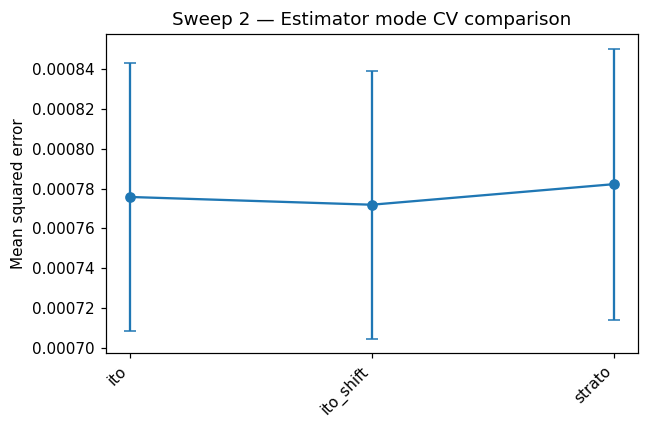

In [11]:
fig_mode_cv = plot_cv_curve(cv_mode)
fig_mode_cv.axes[0].set_title("Sweep 2 — Estimator mode CV comparison")
plt.show()

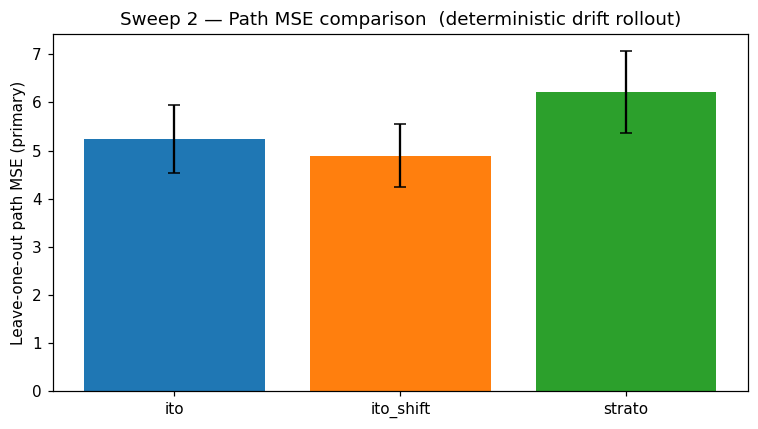

In [12]:
fig_mode_rollout, ax_mode_rollout = plt.subplots(figsize=(7, 4))
mode_labels = list(ESTIMATOR_MODES)
mode_rollout_means = [rollout_path_score(rollout_mode[m]) for m in mode_labels]
mode_rollout_stds = [rollout_path_se(rollout_mode[m]) for m in mode_labels]
ax_mode_rollout.bar(
    np.arange(len(mode_labels)),
    mode_rollout_means,
    yerr=mode_rollout_stds,
    capsize=4,
    color=["C0", "C1", "C2"][: len(mode_labels)],
)
ax_mode_rollout.set_xticks(np.arange(len(mode_labels)))
ax_mode_rollout.set_xticklabels(mode_labels)
ax_mode_rollout.set_ylabel("Leave-one-out path MSE (primary)")
ax_mode_rollout.set_title(
    "Sweep 2 — Path MSE comparison  (deterministic drift rollout)"
)
fig_mode_rollout.tight_layout()
plt.show()

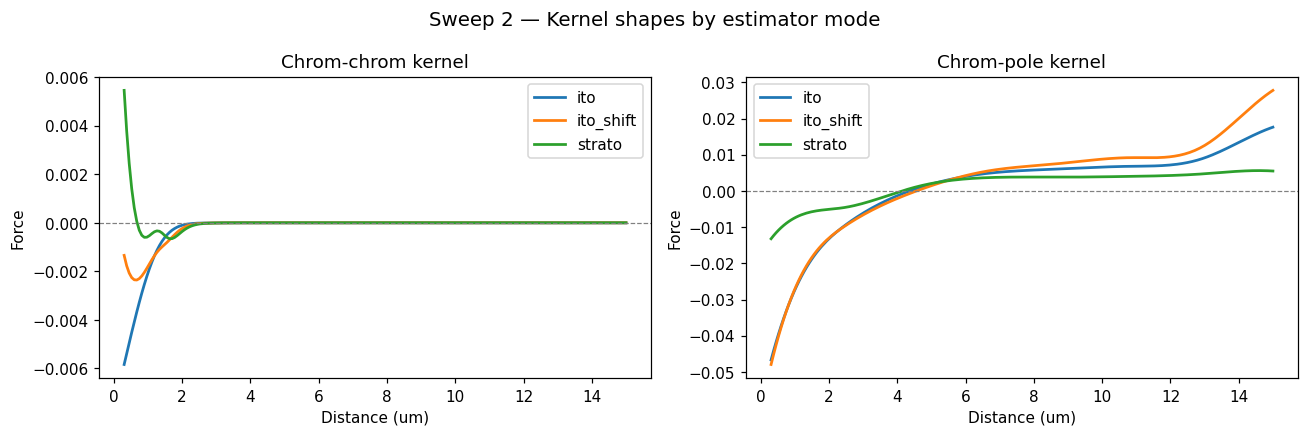


Best estimator mode by 1-step CV: ito_shift  (CV MSE = 7.7188e-04)
Best estimator mode by path MSE (primary): ito_shift  (path MSE = 4.8909e+00)


In [13]:
# Kernel shapes overlaid for each estimator mode
topology_has_chroms = WINNING_TOPOLOGY in ("poles_and_chroms", "center_and_chroms")
n_panels = 2 if topology_has_chroms else 1
MODE_COLORS = {"ito": "C0", "ito_shift": "C1", "strato": "C2"}

fig_mode_kernels, axes_mode_k = plt.subplots(
    1, n_panels, figsize=(6 * n_panels, 4), squeeze=False,
)

n_points = 200
for mode in ESTIMATOR_MODES:
    model: FittedModel = models_mode[mode]
    color = MODE_COLORS.get(mode, "k")

    if topology_has_chroms:
        r_xx = np.linspace(model.basis_xx.r_min, model.basis_xx.r_max, n_points)
        axes_mode_k[0, 0].plot(r_xx, model.evaluate_kernel("xx", r_xx),
                               color=color, linewidth=1.8, label=mode)

    r_xy = np.linspace(model.basis_xy.r_min, model.basis_xy.r_max, n_points)
    phi_xy = model.basis_xy.evaluate(r_xy)
    col_xy = n_panels - 1
    axes_mode_k[0, col_xy].plot(r_xy, phi_xy @ model.theta_xy,
                                color=color, linewidth=1.8, label=mode)

if topology_has_chroms:
    axes_mode_k[0, 0].axhline(0.0, color="0.5", linestyle="--", linewidth=0.8)
    axes_mode_k[0, 0].set_xlabel("Distance (um)")
    axes_mode_k[0, 0].set_ylabel("Force")
    axes_mode_k[0, 0].set_title("Chrom-chrom kernel")
    axes_mode_k[0, 0].legend()

axes_mode_k[0, n_panels - 1].axhline(0.0, color="0.5", linestyle="--", linewidth=0.8)
axes_mode_k[0, n_panels - 1].set_xlabel("Distance (um)")
axes_mode_k[0, n_panels - 1].set_ylabel("Force")
axes_mode_k[0, n_panels - 1].set_title("Chrom-pole kernel")
axes_mode_k[0, n_panels - 1].legend()

fig_mode_kernels.suptitle("Sweep 2 — Kernel shapes by estimator mode", fontsize=13)
fig_mode_kernels.tight_layout()
plt.show()

best_mode = min(cv_mode, key=lambda k: cv_mode[k].mean_error)
best_mode_rollout = min(rollout_mode, key=lambda k: rollout_path_score(rollout_mode[k]))
print(f"\nBest estimator mode by 1-step CV: {best_mode}  (CV MSE = {cv_mode[best_mode].mean_error:.4e})")
print(
    f"Best estimator mode by path MSE (primary): {best_mode_rollout}"
    f"  (path MSE = {rollout_path_score(rollout_mode[best_mode_rollout]):.4e})"
)

## Sweep 3: Endpoint fraction

Sweep the NEB-to-AO fraction, focusing on the early-phase regime where the
gathering dynamics are most active. We also try end_sep using the legacy
normalized spindle-separation velocity rule, clipped before AO.

In [14]:
ENDPOINT_FRACS = [0.15, 0.2, 0.25, 0.33, 0.4, 0.5]

raw_cells = cells_raw
print(f"Using {len(raw_cells)} raw CellData objects for endpoint sweep.")

Using 12 raw CellData objects for endpoint sweep.


In [15]:
cv_endpoint: dict[str, CVResult] = {}
rollout_endpoint: dict[str, RolloutCVResult] = {}
n_cells_endpoint: dict[str, int] = {}

# Sweep neb_ao_frac values
for frac in ENDPOINT_FRACS:
    label = f"frac={frac:.2f}"
    trimmed_method = []
    for raw_cell in raw_cells:
        try:
            trimmed_method.append(trim_trajectory(raw_cell, method="neb_ao_frac", frac=frac))
        except ValueError as exc:
            print(f"  Skipping {raw_cell.cell_id} for {label}: {exc}")

    n_cells_endpoint[label] = len(trimmed_method)
    if len(trimmed_method) < 3:
        print(f"  {label}: only {len(trimmed_method)} cells — skipping CV (too few).")
        continue

    cfg = FitConfig(
        topology=BASE_CONFIG.topology,
        envelope_r0_xx=BASE_CONFIG.envelope_r0_xx,
        envelope_w_xx=BASE_CONFIG.envelope_w_xx,
        n_basis_xx=BASE_CONFIG.n_basis_xx,
        n_basis_xy=BASE_CONFIG.n_basis_xy,
        r_min_xx=BASE_CONFIG.r_min_xx,
        r_max_xx=BASE_CONFIG.r_max_xx,
        r_min_xy=BASE_CONFIG.r_min_xy,
        r_max_xy=BASE_CONFIG.r_max_xy,
        basis_type=BASE_CONFIG.basis_type,
        lambda_ridge=BASE_CONFIG.lambda_ridge,
        lambda_rough=BASE_CONFIG.lambda_rough,
        basis_eval_mode=BASE_CONFIG.basis_eval_mode,
        endpoint_method="neb_ao_frac",
        endpoint_frac=frac,
        diffusion_mode=BASE_CONFIG.diffusion_mode,
        dt=BASE_CONFIG.dt,
    )
    print(f"[Sweep 3 {label}] running 1-step LOOCV...", flush=True)
    cv_endpoint[label] = cross_validate(trimmed_method, cfg)
    print(
        f"    n_cells={len(trimmed_method)}"
        f"  1-step CV = {cv_endpoint[label].mean_error:.4e}"
        f" ± {cv_endpoint[label].fold_se:.4e}",
        flush=True,
    )
    print(
        f"    running deterministic rollout LOOCV ({len(trimmed_method)} folds)...",
        flush=True,
    )
    rollout_endpoint[label] = run_rollout_cv(trimmed_method, cfg)
    print(
        f"    path MSE = {rollout_path_score(rollout_endpoint[label]):.4e}"
        f"  ens MSE @h={H_PRIMARY} = {rollout_ensemble_score(rollout_endpoint[label]):.4e}"
        f"  W1 total = {rollout_w1_score(rollout_endpoint[label]):.4e}",
        flush=True,
    )

# Also try end_sep
trimmed_end_sep = []
for raw_cell in raw_cells:
    try:
        trimmed_end_sep.append(trim_trajectory(raw_cell, method="end_sep"))
    except ValueError as exc:
        print(f"  Skipping {raw_cell.cell_id} for end_sep: {exc}")

n_cells_endpoint["end_sep"] = len(trimmed_end_sep)
if len(trimmed_end_sep) >= 3:
    cfg_es = FitConfig(
        topology=BASE_CONFIG.topology,
        envelope_r0_xx=BASE_CONFIG.envelope_r0_xx,
        envelope_w_xx=BASE_CONFIG.envelope_w_xx,
        n_basis_xx=BASE_CONFIG.n_basis_xx,
        n_basis_xy=BASE_CONFIG.n_basis_xy,
        r_min_xx=BASE_CONFIG.r_min_xx,
        r_max_xx=BASE_CONFIG.r_max_xx,
        r_min_xy=BASE_CONFIG.r_min_xy,
        r_max_xy=BASE_CONFIG.r_max_xy,
        basis_type=BASE_CONFIG.basis_type,
        lambda_ridge=BASE_CONFIG.lambda_ridge,
        lambda_rough=BASE_CONFIG.lambda_rough,
        basis_eval_mode=BASE_CONFIG.basis_eval_mode,
        endpoint_method="end_sep",
        diffusion_mode=BASE_CONFIG.diffusion_mode,
        dt=BASE_CONFIG.dt,
    )
    print("[Sweep 3 end_sep] running 1-step LOOCV...", flush=True)
    cv_endpoint["end_sep"] = cross_validate(trimmed_end_sep, cfg_es)
    print(
        f"    n_cells={len(trimmed_end_sep)}"
        f"  1-step CV = {cv_endpoint['end_sep'].mean_error:.4e}"
        f" ± {cv_endpoint['end_sep'].fold_se:.4e}",
        flush=True,
    )
    print(
        f"    running deterministic rollout LOOCV ({len(trimmed_end_sep)} folds)...",
        flush=True,
    )
    rollout_endpoint["end_sep"] = run_rollout_cv(trimmed_end_sep, cfg_es)
    print(
        f"    path MSE = {rollout_path_score(rollout_endpoint['end_sep']):.4e}"
        f"  ens MSE @h={H_PRIMARY} = {rollout_ensemble_score(rollout_endpoint['end_sep']):.4e}"
        f"  W1 total = {rollout_w1_score(rollout_endpoint['end_sep']):.4e}",
        flush=True,
    )
else:
    print(f"  end_sep: only {len(trimmed_end_sep)} cells — skipping CV (too few).")

[Sweep 3 frac=0.15] running 1-step LOOCV...


    n_cells=12  1-step CV = 9.9556e-04 ± 8.3225e-05


    running deterministic rollout LOOCV (12 folds)...


    path MSE = 1.9151e+00  ens MSE @h=10 = 1.5444e+00  W1 total = 8.4406e-01


[Sweep 3 frac=0.20] running 1-step LOOCV...


...

    path MSE = 7.0003e+00  ens MSE @h=10 = 1.6167e+00  W1 total = 1.9004e+00


[Sweep 3 end_sep] running 1-step LOOCV...


    n_cells=12  1-step CV = 7.8650e-04 ± 7.3581e-05


    running deterministic rollout LOOCV (12 folds)...


    path MSE = 4.4287e+00  ens MSE @h=10 = 1.5818e+00  W1 total = 1.5367e+00


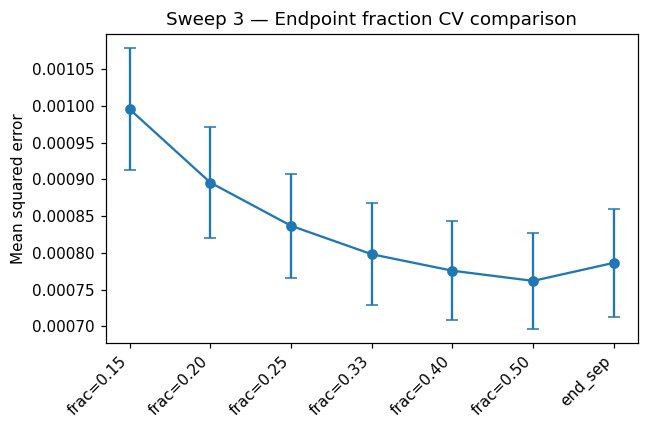

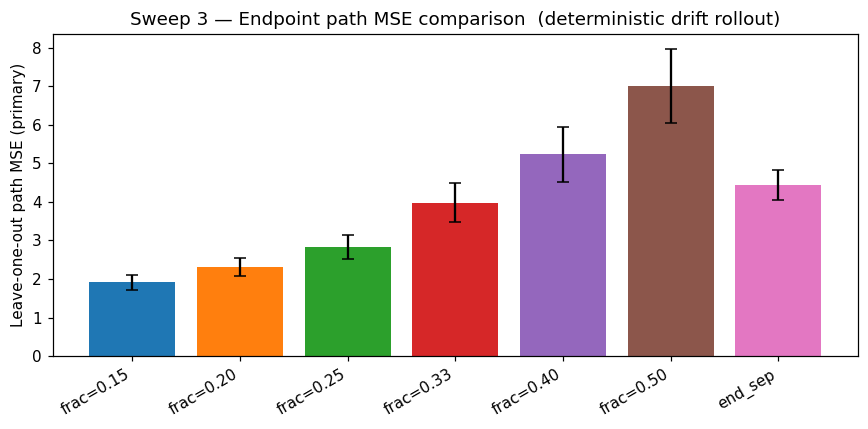


Best endpoint by 1-step CV: frac=0.50  (CV MSE = 7.6191e-04)
Best endpoint by path MSE (primary): frac=0.15  (path MSE = 1.9151e+00)

Cell counts per endpoint setting:
  frac=0.15           : 12 cells
  frac=0.20           : 12 cells
  frac=0.25           : 12 cells
  frac=0.33           : 12 cells
  frac=0.40           : 12 cells
  frac=0.50           : 12 cells
  end_sep             : 12 cells


In [16]:
if cv_endpoint:
    fig_ep = plot_cv_curve(cv_endpoint)
    fig_ep.axes[0].set_title("Sweep 3 — Endpoint fraction CV comparison")
    plt.show()

    endpoint_labels = list(cv_endpoint.keys())
    endpoint_rollout_means = [rollout_path_score(rollout_endpoint[k]) for k in endpoint_labels]
    endpoint_rollout_stds = [rollout_path_se(rollout_endpoint[k]) for k in endpoint_labels]
    fig_ep_rollout, ax_ep_rollout = plt.subplots(figsize=(8, 4))
    ax_ep_rollout.bar(
        np.arange(len(endpoint_labels)),
        endpoint_rollout_means,
        yerr=endpoint_rollout_stds,
        capsize=4,
        color=[f"C{i}" for i in range(len(endpoint_labels))],
    )
    ax_ep_rollout.set_xticks(np.arange(len(endpoint_labels)))
    ax_ep_rollout.set_xticklabels(endpoint_labels, rotation=30, ha="right")
    ax_ep_rollout.set_ylabel("Leave-one-out path MSE (primary)")
    ax_ep_rollout.set_title(
        "Sweep 3 — Endpoint path MSE comparison  (deterministic drift rollout)"
    )
    fig_ep_rollout.tight_layout()
    plt.show()

    best_endpoint = min(cv_endpoint, key=lambda k: cv_endpoint[k].mean_error)
    best_endpoint_rollout = min(
        rollout_endpoint, key=lambda k: rollout_path_score(rollout_endpoint[k])
    )
    print(f"\nBest endpoint by 1-step CV: {best_endpoint}  (CV MSE = {cv_endpoint[best_endpoint].mean_error:.4e})")
    print(
        f"Best endpoint by path MSE (primary): {best_endpoint_rollout}"
        f"  (path MSE = {rollout_path_score(rollout_endpoint[best_endpoint_rollout]):.4e})"
    )
else:
    print("No endpoint settings produced enough cells for CV.")

print("\nCell counts per endpoint setting:")
for label in list(f"frac={f:.2f}" for f in ENDPOINT_FRACS) + ["end_sep"]:
    print(f"  {label:20s}: {n_cells_endpoint.get(label, 0)} cells")

## Summary

Headline question: what hyperparameters are reasonable for the kernel fit?
We use the same primary criterion as NB04 (deterministic drift-rollout
path MSE -- full-trajectory ensemble MSE) so the answers are directly aligned.

In [17]:
print("=" * 70)
print("Hyperparameter sensitivity summary  (primary metric: path MSE)")
print("=" * 70)
best_grid_score = rollout_path_score(grid_rollout[best_key])
print(f"  {'Joint grid n_basis':<30} {best_n_basis_rollout:<14} {best_grid_score:.4e}")
print(f"  {'Joint grid lambda_rough':<30} {best_rough_rollout:<14.2e} {best_grid_score:.4e}")
print(f"  {'basis_eval_mode':<30} {best_mode_rollout:<14} "
      f"{rollout_path_score(rollout_mode[best_mode_rollout]):.4e}")
if cv_endpoint:
    print(f"  {'endpoint_method':<30} {best_endpoint_rollout:<14} "
          f"{rollout_path_score(rollout_endpoint[best_endpoint_rollout]):.4e}")
print("=" * 70)
print(f"  lambda_ridge fixed at {LAMBDA_RIDGE:.0e} throughout (numerical jitter only;")
print("  not interpreting individual basis coefficients, only kernel function output).")

Hyperparameter sensitivity summary  (primary metric: path MSE)
  Joint grid n_basis             12             5.2219e+00
  Joint grid lambda_rough        1.00e+02       5.2219e+00
  basis_eval_mode                ito_shift      4.8909e+00
  endpoint_method                frac=0.15      1.9151e+00
  lambda_ridge fixed at 1e-06 throughout (numerical jitter only;
  not interpreting individual basis coefficients, only kernel function output).
